In [1]:
import nd2
import cv2
import matplotlib.pyplot as plt
import numpy as np
import dask.array as da
from pathlib import Path
from scipy.ndimage import gaussian_filter

scale = 0.11
interval = 4
sigma = (0.0, 1.0, 1.0)

p_dir = Path('/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp')

p_file = p_dir / 'exp.nd2'
file = nd2.imread(p_file, dask = True)

images = file[0:271, 1, :, :]

images_blur = gaussian_filter(images, sigma)

In [2]:
def comp8bit(img_u16):
    # 1. 最小値と最大値を計算（ここが一番コストが高い）
    p_min, p_max = img_u16.min(), img_u16.max()
    
    # 2. 0-255に収めるための係数を計算
    diff = p_max - p_min
    if diff == 0:
        return np.zeros_like(img_u16, dtype=np.uint8)
    
    scale = 255.0 / diff
    
    # 3. 演算を一つにまとめて、最後にキャスト
    # (x - min) * scale を一気に行う
    return ((img_u16 - p_min) * scale).astype(np.uint8)

images_8bit = comp8bit(images_blur)

In [ ]:
from tqdm import tqdm

import cv2
import numpy as np
from tqdm import tqdm

def compute_flow(images, params):
    t_len = images.shape[0]
    h, w = images.shape[1], images.shape[2]
    
    if t_len <= 1:
        return np.empty((0, h, w, 2), dtype=np.float32)
    
    flows = np.empty((t_len - 1, h, w, 2), dtype=np.float32)
    current_flow = np.zeros((h, w, 2), np.float32)

    # images が Dask 配列の場合に備え、ループ内で実体化させる
    for i in tqdm(range(t_len - 1), desc="Computing Optical Flow"):
        # 【修正ポイント】np.asarray() で NumPy 配列に変換（実体化）
        prev_img = np.asarray(images[i])
        next_img = np.asarray(images[i+1])
        
        # データ型を確実に uint8 にする（念のため）
        if prev_img.dtype != np.uint8:
            prev_img = prev_img.astype(np.uint8)
        if next_img.dtype != np.uint8:
            next_img = next_img.astype(np.uint8)

        if i == 0:
            flow_flags = 0 
        else:
            flow_flags = cv2.OPTFLOW_USE_INITIAL_FLOW
            
        current_flow = cv2.calcOpticalFlowFarneback(
            prev_img, 
            next_img, 
            current_flow, 
            **params, 
            flags=flow_flags
        )
        
        flows[i] = current_flow
        
    return flows

# 移動量 18px に最適化したパラメータ
params = dict(
    pyr_scale=0.5, 
    levels=5,          # 階層を増やす（18pxなら5層以上必要）
    winsize=3,        # 移動量よりも大きいサイズを確保。2倍程度が安定
    iterations=10, 
    poly_n=7,          # 大きな動きにはより滑らかな近似（7）が有効
    poly_sigma=1.5
)

flows = compute_flow(images_8bit, params)

Computing Optical Flow: 100%|██████████| 270/270 [02:40<00:00,  1.68it/s]


In [ ]:
# ベクトル強度 (pixel/frame)
mag = np.linalg.norm(flows, axis=-1)

# 物理単位への変換係数
# 1px(縮小後) = 0.11 / 0.25 um
# 時間 = 4 s

conversion_factor = scale /interval
velocity_um_s = mag * conversion_factor

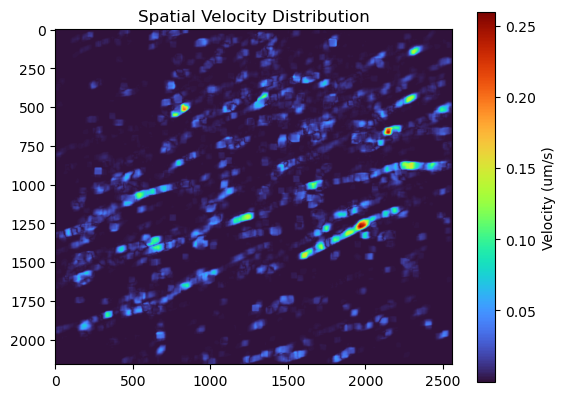

In [98]:
import matplotlib.pyplot as plt

# 特定のフレームの速度マップを表示
plt.imshow(velocity_um_s[0], cmap='turbo')
plt.colorbar(label='Velocity (um/s)')
plt.title("Spatial Velocity Distribution")
plt.show()

In [170]:
params = dict(
    pyr_scale = 0.5, 
    levels = 7,          # 階層を増やす（18pxなら5層以上必要）
    winsize = 21,        # 移動量よりも大きいサイズを確保。2倍程度が安定
    iterations = 10, 
    poly_n = 7,          # 大きな動きにはより滑らかな近似（7）が有効
    poly_sigma = 1
)

test_flow = cv2.calcOpticalFlowFarneback(
            images_8bit[0], 
            images_8bit[1], 
            0, 
            **params, 
            flags=None
        )

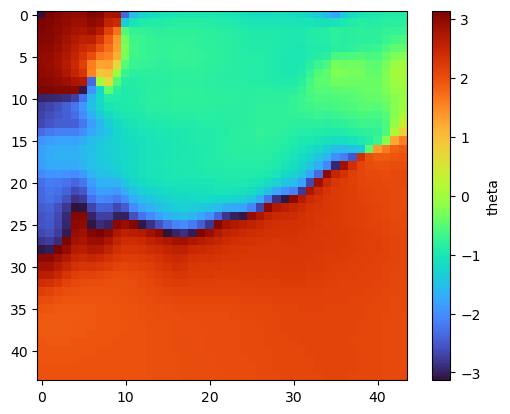

In [172]:
scale = 0.11
width = 5
center = 1200

l = int(width/(2*scale))

x = test_flow[center-l:center+l, center-l:center+l, 0]
y = test_flow[center-l:center+l, center-l:center+l, 1]
"""
x = test_flow[:, :, 0]
y = test_flow[:, :, 1]
"""
theta = np.arctan2(x, y)

plt.imshow(theta, cmap='turbo')
plt.colorbar(label='theta')

In [166]:
# ベクトル強度 (pixel/frame)
mag_test = np.linalg.norm(test_flow, axis=-1)

# 物理単位への変換係数
# 1px(縮小後) = 0.11 um
# 時間 = 4 s / frame

conversion_factor = scale /interval
velocity_um_s_test = mag_test * conversion_factor

In [167]:
v_min = 0.0
velocity_um_s_test_filtered = np.where(v_min < velocity_um_s_test, velocity_um_s_test, np.nan)

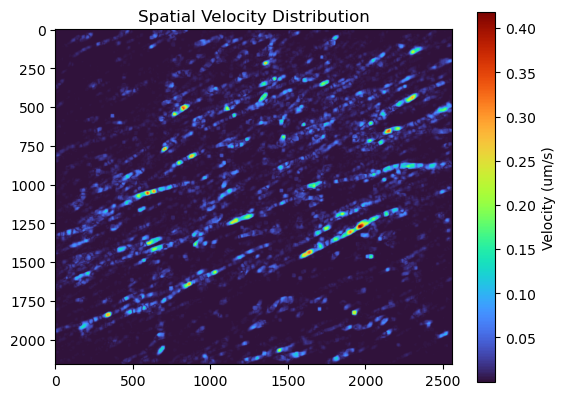

In [173]:
import matplotlib.pyplot as plt

# 特定のフレームの速度マップを表示
plt.imshow(velocity_um_s_test_filtered, cmap='turbo')
plt.colorbar(label='Velocity (um/s)')
plt.title("Spatial Velocity Distribution")
plt.show()

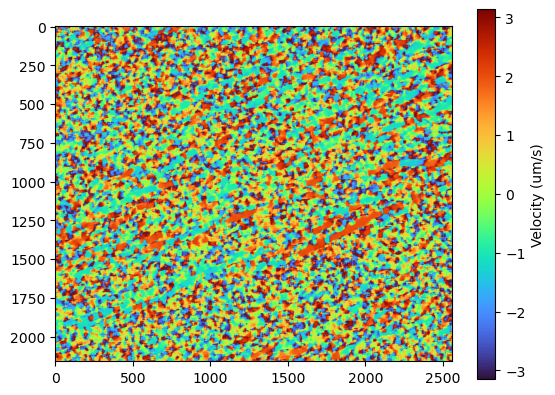

In [169]:
x = test_flow[:,:,0]
y = test_flow[:,:,1]

theta = np.arctan2(x, y)

plt.imshow(theta, cmap='turbo')
plt.colorbar(label='Velocity (um/s)')